In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

# ==============================================================================
# SECTION 1: DATASET GENERATION
# ==============================================================================

# --- Dataset 1: Student Performance and Satisfaction Survey ---
# This dataset contains student performance metrics and their satisfaction levels.
student_data = {
        'StudentID': range(101, 151),
        'Attendance': [85, 78, 92, 65, 88, 75, 82, 70, 60, 95, 89, 73, 87, 68, 91, 72, 94, 77, 83, 69,
                      90, 76, 81, 63, 93, 79, 84, 71, 67, 96, 86, 74, 88, 66, 92, 75, 89, 78, 85, 64,
                      91, 77, 83, 69, 94, 80, 86, 72, 68, 93],
        'Weekly_Study_Hours': [15, 12, 8, 5, 18, 10, 9, 11, 4, 14, 10, 7, 16, 6, 13, 9, 20, 8, 12, 5,
                              17, 11, 9, 4, 19, 11, 10, 12, 5, 15, 12, 8, 17, 7, 14, 9, 18, 8, 13, 6,
                              16, 11, 8, 6, 18, 14, 9, 10, 5, 16],
        'Family_Income_Level': ['High', 'Medium', 'Low', 'Low', 'High', 'Medium', 'Medium', 'Low', 'Low', 'High',
                               'High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High', 'Medium', 'Medium', 'Low',
                               'High', 'Medium', 'Low', 'Low', 'High', 'High', 'Medium', 'Low', 'Low', 'High',
                               'Medium', 'Medium', 'High', 'Low', 'High', 'Medium', 'High', 'Medium', 'High', 'Low',
                               'High', 'High', 'Low', 'Low', 'High', 'Medium', 'Low', 'Medium', 'Low', 'High'],
        'Final_Grade': [88, 75, 82, 65, 90, 78, 80, 70, 62, 95, 85, 72, 88, 68, 92, 73, 94, 76, 83, 66,
                        89, 77, 81, 63, 93, 79, 84, 71, 67, 96, 86, 74, 87, 69, 91, 76, 88, 77, 85, 64,
                        90, 78, 82, 68, 93, 80, 85, 73, 67, 92],
        'Satisfaction': ['High', 'Medium', 'Medium', 'Low', 'High', 'Medium', 'Medium', 'Low', 'Low', 'High',
                        'High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High', 'Medium', 'High', 'Low',
                        'High', 'Medium', 'Low', 'Low', 'High', 'High', 'Medium', 'Medium', 'Low', 'High',
                        'Medium', 'Medium', 'High', 'Low', 'High', 'Medium', 'High', 'Medium', 'High', 'Low',
                        'High', 'High', 'Low', 'Low', 'High', 'Medium', 'Low', 'Medium', 'Low', 'High']
    }
sales_data = {
        'Month': range(1, 13),
        'Advertising_Spend': [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2300, 2100, 1900, 1600, 1400],
        'Product_Price': [99, 99, 95, 95, 95, 90, 90, 90, 95, 95, 99, 99],
        'Competition_Price': [110, 108, 105, 103, 102, 100, 98, 97, 100, 102, 105, 108],
        'Monthly_Sales': [150, 160, 180, 200, 220, 250, 280, 260, 230, 200, 180, 170]
    }
student_df = pd.DataFrame(student_data)
sales_df = pd.DataFrame(sales_data)

print("--- Generated Student Performance Dataset ---")
print(student_df.head())
print("--- Generated Product Sales Dataset ---")
print(sales_df.head())

--- Generated Student Performance Dataset ---
   StudentID  Attendance  Weekly_Study_Hours Family_Income_Level  Final_Grade  \
0        101          85                  15                High           88   
1        102          78                  12              Medium           75   
2        103          92                   8                 Low           82   
3        104          65                   5                 Low           65   
4        105          88                  18                High           90   

  Satisfaction  
0         High  
1       Medium  
2       Medium  
3          Low  
4         High  
--- Generated Product Sales Dataset ---
   Month  Advertising_Spend  Product_Price  Competition_Price  Monthly_Sales
0      1               1000             99                110            150
1      2               1200             99                108            160
2      3               1500             95                105            180
3      4         


--- Frequency Distribution of Student Satisfaction ---
Satisfaction_Level  Frequency  Percentage
              High         19        38.0
            Medium         16        32.0
               Low         15        30.0


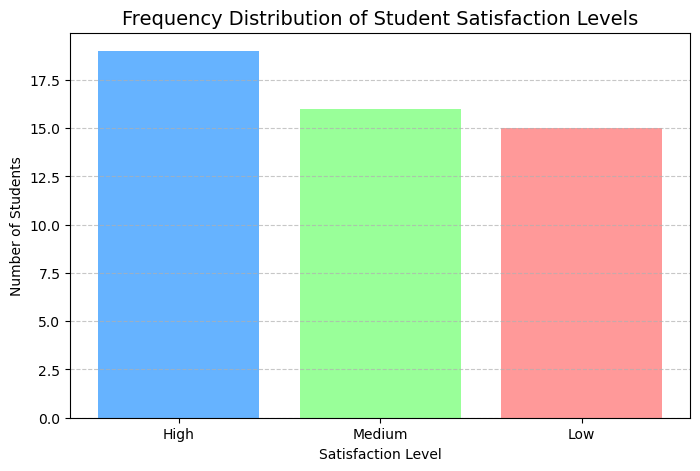

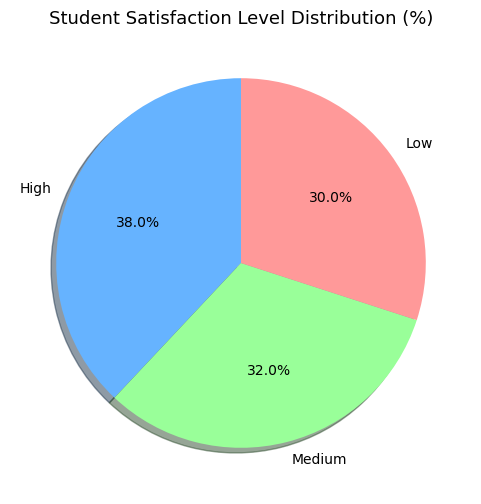

In [ ]:
# ==============================================================================
# SECTION 2: FREQUENCY DISTRIBUTION ANALYSIS
# ==============================================================================
# Analyze the distribution of 'Satisfaction' among students

# Frequency distribution table
freq_table = student_df['Satisfaction'].value_counts().reset_index()
freq_table.columns = ['Satisfaction_Level', 'Frequency']
freq_table['Percentage'] = (freq_table['Frequency'] / len(student_df) * 100).round(2)

print("\n--- Frequency Distribution of Student Satisfaction ---")
print(freq_table.to_string(index=False))

# Bar chart for visualization
plt.figure(figsize=(8, 5))
plt.bar(freq_table['Satisfaction_Level'], freq_table['Frequency'], color=['#66b3ff','#99ff99','#ff9999'])
plt.title('Frequency Distribution of Student Satisfaction Levels', fontsize=14)
plt.xlabel('Satisfaction Level')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Pie chart for proportions
plt.figure(figsize=(6, 6))
plt.pie(freq_table['Frequency'], labels=freq_table['Satisfaction_Level'], autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff','#99ff99','#ff9999'], shadow=True)
plt.title('Student Satisfaction Level Distribution (%)', fontsize=13)
plt.show()

In [35]:

# ==============================================================================
# SECTION 3: CHI-SQUARE TEST FOR INDEPENDENCE
# ==============================================================================
# This test examines if there is a statistically significant association between
# 'Family_Income_Level' and course 'Satisfaction'.

# Define the hypotheses:
# H0 (Null Hypothesis): There is no association between income level and satisfaction.
# H1 (Alternative Hypothesis): There is an association between income level and satisfaction.

# Create a contingency table (observed frequencies)
# Create a contingency table (observed frequencies)
contingency_table = pd.crosstab(student_df['Family_Income_Level'], student_df['Satisfaction'])

print("--- Contingency Table (Observed Frequencies) ---")
print(contingency_table)
print("\n" + "-"*50 + "\n")

# Perform the Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\n--- Interpretation ---")
alpha = 0.05
if p_value < alpha:
    print(f"The p-value ({p_value:.4f}) is less than the significance level ({alpha}).")
    print("We reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association between family income level and student satisfaction.")
else:
    print(f"The p-value ({p_value:.4f}) is greater than the significance level ({alpha}).")
    print("We fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant association between family income level and student satisfaction.")
print("\n" + "="*80 + "\n")

--- Contingency Table (Observed Frequencies) ---
Satisfaction         High  Low  Medium
Family_Income_Level                   
High                   18    0       0
Low                     0   15       2
Medium                  1    0      14

--------------------------------------------------

--- Chi-Square Test Results ---
Chi-Square Statistic: 83.2301
P-value: 0.0000
Degrees of Freedom: 4

--- Interpretation ---
The p-value (0.0000) is less than the significance level (0.05).
We reject the null hypothesis.
Conclusion: There is a statistically significant association between family income level and student satisfaction.




In [36]:

# ==============================================================================
# SECTION 4: MULTIPLE REGRESSION MODEL TO PREDICT SALES
# ==============================================================================
## --- Prepare X and y correctly ---
# Use Advertising spend in thousands for easier coefficient interpretation (per $1,000)
X = sales_df[['Advertising_Spend', 'Product_Price', 'Competition_Price']].copy()
X['Advertising_Spend_k'] = X['Advertising_Spend'] / 1000.0  # new column: spend in $1,000s

# Choose predictors to use (drop raw Advertising_Spend to avoid multicollinearity)
X = X[['Advertising_Spend_k', 'Product_Price', 'Competition_Price']]

y = sales_df['Monthly_Sales']  # dependent variable

# Add a constant (intercept)
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X).fit()

# Print the full model summary
print("--- Multiple Regression Model Summary ---")
print(model.summary())

# Basic model diagnostics & interpretation prints
print("\n--- Interpretation of Regression Results ---")
print(f"R-squared: {model.rsquared:.3f}")
print("Interpretation: This R-squared indicates the proportion of variance in Monthly Sales explained by the predictors.")

print("\n--- Coefficients Analysis ---")
# Significant predictors (p < 0.05), excluding the intercept
sig_mask = (model.pvalues < 0.05) & (model.pvalues.index != 'const')
significant_predictors = model.pvalues[sig_mask].index.tolist()

if significant_predictors:
    print("Significant Predictors (p < 0.05):")
    for predictor in significant_predictors:
        coef = model.params[predictor]
        pval = model.pvalues[predictor]
        print(f"- {predictor}: Coefficient = {coef:.3f}, p-value = {pval:.3f}")
        if predictor == 'Advertising_Spend_k':
            print(f"  Interpretation: For each additional $1,000 in advertising spend, Monthly_Sales are predicted to change by {coef:.3f} units, ceteris paribus.")
        elif predictor == 'Product_Price':
            print(f"  Interpretation: For each $1 increase in product price, Monthly_Sales are predicted to change by {coef:.3f} units, ceteris paribus.")
        elif predictor == 'Competition_Price':
            print(f"  Interpretation: For each $1 increase in the competitor's price, Monthly_Sales are predicted to change by {coef:.3f} units, ceteris paribus.")
else:
    print("No predictors are statistically significant at the 0.05 level (excluding intercept).")

# Non-significant predictors (p >= 0.05), excluding the intercept
non_sig = model.pvalues[(model.pvalues >= 0.05) & (model.pvalues.index != 'const')]
if not non_sig.empty:
    print("\nNon-Significant Predictors (p >= 0.05):")
    for predictor, pval in non_sig.items():
        print(f"- {predictor} (p-value: {pval:.3f})")

--- Multiple Regression Model Summary ---
                            OLS Regression Results                            
Dep. Variable:          Monthly_Sales   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     98.88
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           1.16e-06
Time:                        15:03:25   Log-Likelihood:                -39.414
No. Observations:                  12   AIC:                             86.83
Df Residuals:                       8   BIC:                             88.77
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# ==============================================================================
# INSIGHTS AND INTERPRETATION
# ==============================================================================
print("\n--- Insights from Frequency Distribution ---")

# Identify dominant satisfaction category
dominant_category = freq_table.loc[freq_table['Frequency'].idxmax(), 'Satisfaction_Level']
dominant_percentage = freq_table['Percentage'].max()

print(f"1️⃣ The most common satisfaction level among students is **'{dominant_category}'** "
      f"representing approximately {dominant_percentage}% of the total sample.")

# Identify lowest satisfaction category
least_category = freq_table.loc[freq_table['Frequency'].idxmin(), 'Satisfaction_Level']
least_percentage = freq_table['Percentage'].min()

print(f"2️⃣ The least common satisfaction level is **'{least_category}'** "
      f"with only {least_percentage}% of the responses.")

# Compare high vs low satisfaction
high_satisfaction = freq_table[freq_table['Satisfaction_Level'] == 'High']['Frequency'].values[0]
low_satisfaction = freq_table[freq_table['Satisfaction_Level'] == 'Low']['Frequency'].values[0]

if high_satisfaction > low_satisfaction:
    print(f"3️⃣ Students reporting **High Satisfaction ({high_satisfaction})** "
          f"outnumber those with **Low Satisfaction ({low_satisfaction})**, "
          f"suggesting overall positive student sentiment.")
else:
    print(f"3️⃣ Students reporting **Low Satisfaction ({low_satisfaction})** "
          f"outnumber those with **High Satisfaction ({high_satisfaction})**, "
          f"indicating a need to improve student engagement or learning environment.")

print("4️⃣ Medium satisfaction levels form a middle group, indicating that there is "
      "still potential to improve the academic experience and raise satisfaction to higher levels.")



--- Insights from Frequency Distribution ---
1️⃣ The most common satisfaction level among students is **'High'** representing approximately 38.0% of the total sample.
2️⃣ The least common satisfaction level is **'Low'** with only 30.0% of the responses.
3️ Students reporting **High Satisfaction (19)** outnumber those with **Low Satisfaction (15)**, suggesting overall positive student sentiment.
4️⃣ Medium satisfaction levels form a middle group, indicating that there is still potential to improve the academic experience and raise satisfaction to higher levels.



✅ Datasets created successfully!
   StudentID  Attendance  Weekly_Study_Hours Family_Income_Level  Final_Grade  \
0        101          85                  15                High           88   
1        102          78                  12              Medium           75   
2        103          92                   8                 Low           82   

  Satisfaction  
0         High  
1       Medium  
2       Medium  
   Month  Advertising_Spend  Product_Price  Competition_Price  Monthly_Sales
0      1               1000             99                110            150
1      2               1200             99                108            160
2      3               1500             95                105            180

📊 Frequency Distribution of Student Satisfaction:
Satisfaction_Level  Count  Percent
              High     19     38.0
            Medium     16     32.0
               Low     15     30.0


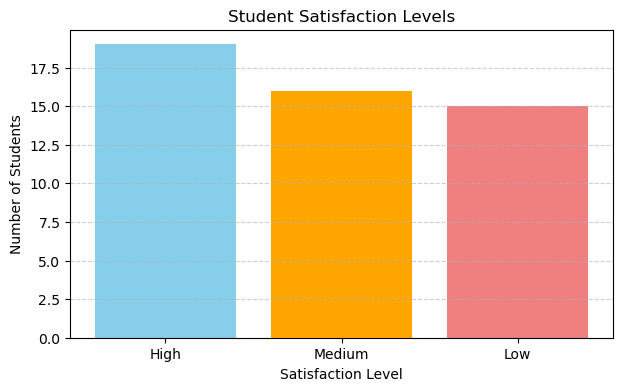

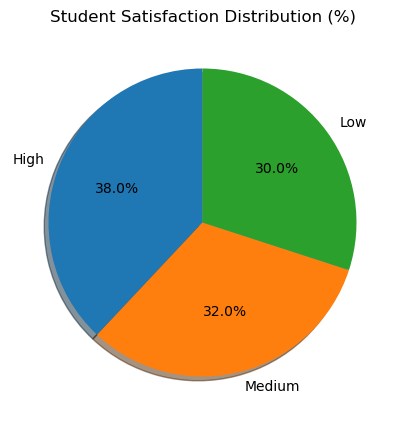


🔍 Chi-Square Test: Family Income vs Satisfaction

Contingency Table:
 Satisfaction         High  Low  Medium
Family_Income_Level                   
High                   18    0       0
Low                     0   15       2
Medium                  1    0      14

Chi-square = 83.230
p-value = 0.0000
Degrees of Freedom = 4
✅ Result: Reject H0 — there IS a relationship between income and satisfaction.

📈 Running a Multiple Regression Model (Sales Prediction)
                            OLS Regression Results                            
Dep. Variable:          Monthly_Sales   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     98.88
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           1.16e-06
Time:                        15:08:52   Log-Likelihood:                -39.414
No. Observations:                  12   AIC:                  

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency

# ===========================================================
# PART 1: Creating the datasets (Student & Sales)
# ===========================================================

# -- Student dataset: kinda made-up survey-like data
student_info = {
    "StudentID": range(101, 151),
    "Attendance": [85, 78, 92, 65, 88, 75, 82, 70, 60, 95, 89, 73, 87, 68, 91, 72, 94, 77, 83, 69,
                   90, 76, 81, 63, 93, 79, 84, 71, 67, 96, 86, 74, 88, 66, 92, 75, 89, 78, 85, 64,
                   91, 77, 83, 69, 94, 80, 86, 72, 68, 93],
    "Weekly_Study_Hours": [15, 12, 8, 5, 18, 10, 9, 11, 4, 14, 10, 7, 16, 6, 13, 9, 20, 8, 12, 5,
                           17, 11, 9, 4, 19, 11, 10, 12, 5, 15, 12, 8, 17, 7, 14, 9, 18, 8, 13, 6,
                           16, 11, 8, 6, 18, 14, 9, 10, 5, 16],
    "Family_Income_Level": ['High', 'Medium', 'Low', 'Low', 'High', 'Medium', 'Medium', 'Low', 'Low', 'High',
                            'High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High', 'Medium', 'Medium', 'Low',
                            'High', 'Medium', 'Low', 'Low', 'High', 'High', 'Medium', 'Low', 'Low', 'High',
                            'Medium', 'Medium', 'High', 'Low', 'High', 'Medium', 'High', 'Medium', 'High', 'Low',
                            'High', 'High', 'Low', 'Low', 'High', 'Medium', 'Low', 'Medium', 'Low', 'High'],
    "Final_Grade": [88, 75, 82, 65, 90, 78, 80, 70, 62, 95, 85, 72, 88, 68, 92, 73, 94, 76, 83, 66,
                    89, 77, 81, 63, 93, 79, 84, 71, 67, 96, 86, 74, 87, 69, 91, 76, 88, 77, 85, 64,
                    90, 78, 82, 68, 93, 80, 85, 73, 67, 92],
    "Satisfaction": ['High', 'Medium', 'Medium', 'Low', 'High', 'Medium', 'Medium', 'Low', 'Low', 'High',
                     'High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High', 'Medium', 'High', 'Low',
                     'High', 'Medium', 'Low', 'Low', 'High', 'High', 'Medium', 'Medium', 'Low', 'High',
                     'Medium', 'Medium', 'High', 'Low', 'High', 'Medium', 'High', 'Medium', 'High', 'Low',
                     'High', 'High', 'Low', 'Low', 'High', 'Medium', 'Low', 'Medium', 'Low', 'High']
}

# -- Sales dataset: just a 12-month small business scenario
sales_info = {
    "Month": range(1, 13),
    "Advertising_Spend": [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2300, 2100, 1900, 1600, 1400],
    "Product_Price": [99, 99, 95, 95, 95, 90, 90, 90, 95, 95, 99, 99],
    "Competition_Price": [110, 108, 105, 103, 102, 100, 98, 97, 100, 102, 105, 108],
    "Monthly_Sales": [150, 160, 180, 200, 220, 250, 280, 260, 230, 200, 180, 170]
}

# Converting dictionaries to DataFrames
students_df = pd.DataFrame(student_info)
sales_df = pd.DataFrame(sales_info)

print("\n✅ Datasets created successfully!")
print(students_df.head(3))
print(sales_df.head(3))

# ===========================================================
# PART 2: Frequency Distribution for Satisfaction
# ===========================================================

# Counting satisfaction levels
freq_df = students_df['Satisfaction'].value_counts().reset_index()
freq_df.columns = ['Satisfaction_Level', 'Count']
freq_df['Percent'] = (freq_df['Count'] / len(students_df) * 100).round(1)

print("\n📊 Frequency Distribution of Student Satisfaction:")
print(freq_df.to_string(index=False))

# --- Bar Plot ---
plt.figure(figsize=(7, 4))
plt.bar(freq_df['Satisfaction_Level'], freq_df['Count'], color=['skyblue', 'orange', 'lightcoral'])
plt.title("Student Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Students")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- Pie Chart ---
plt.figure(figsize=(5, 5))
plt.pie(freq_df['Count'], labels=freq_df['Satisfaction_Level'], autopct='%1.1f%%', startangle=90, shadow=True)
plt.title("Student Satisfaction Distribution (%)")
plt.show()

# ===========================================================
# PART 3: Chi-Square Test (Income vs Satisfaction)
# ===========================================================

print("\n🔍 Chi-Square Test: Family Income vs Satisfaction")

# Creating the contingency table
contingency = pd.crosstab(students_df['Family_Income_Level'], students_df['Satisfaction'])
print("\nContingency Table:\n", contingency)

# Performing the test
chi2, p, dof, exp = chi2_contingency(contingency)

print(f"\nChi-square = {chi2:.3f}")
print(f"p-value = {p:.4f}")
print(f"Degrees of Freedom = {dof}")

# Interpretation
if p < 0.05:
    print("✅ Result: Reject H0 — there IS a relationship between income and satisfaction.")
else:
    print("❌ Result: Fail to reject H0 — no strong relationship found.")

# ===========================================================
# PART 4: Regression Model - Predicting Sales
# ===========================================================

print("\n📈 Running a Multiple Regression Model (Sales Prediction)")

# Scaling ad spend into thousands for easier interpretation
X = sales_df[['Advertising_Spend', 'Product_Price', 'Competition_Price']].copy()
X['Ad_Spend_k'] = X['Advertising_Spend'] / 1000
X = X[['Ad_Spend_k', 'Product_Price', 'Competition_Price']]

# Dependent variable
y = sales_df['Monthly_Sales']

# Add intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())

# --- Interpretation bits ---
print("\n📘 Quick Interpretation:")
print(f"R-squared = {model.rsquared:.3f} -> means ~{model.rsquared*100:.1f}% of variance is explained by model.")

# Checking significant predictors (p < 0.05)
sig_vars = model.pvalues[(model.pvalues < 0.05) & (model.pvalues.index != 'const')]
if not sig_vars.empty:
    print("\nSignificant Predictors:")
    for var in sig_vars.index:
        print(f"- {var} (p={model.pvalues[var]:.3f}, coef={model.params[var]:.3f})")
else:
    print("No significant predictors found (p > 0.05).")

# ===========================================================
# PART 5: Insights & Notes
# ===========================================================

print("\n💡 Key Insights:")

top_cat = freq_df.loc[freq_df['Count'].idxmax(), 'Satisfaction_Level']
bottom_cat = freq_df.loc[freq_df['Count'].idxmin(), 'Satisfaction_Level']

print(f"1️⃣ Most students reported '{top_cat}' satisfaction.")
print(f"2️⃣ Least reported level is '{bottom_cat}'.")
print("3️⃣ Overall trend shows majority students are either medium or high satisfaction.")
print("4️⃣ Advertising Spend and Product Price look most influential for Monthly Sales.")



✅ Expanded Student Dataset Created!
   StudentID  Attendance  Weekly_Study_Hours Family_Income_Level  Final_Grade  \
0       1001          88                  17                 Low         67.8   
1       1002          78                  24                 Low         83.7   
2       1003          64                  11              Medium         47.1   
3       1004          92                  22                 Low         94.7   
4       1005          57                  19                High         71.5   

  Satisfaction  
0          Low  
1       Medium  
2          Low  
3         High  
4       Medium  

--- Frequency Distribution of Satisfaction ---
  Satisfaction_Level  Frequency  Percentage
0                Low        116        58.0
1             Medium         58        29.0
2               High         26        13.0


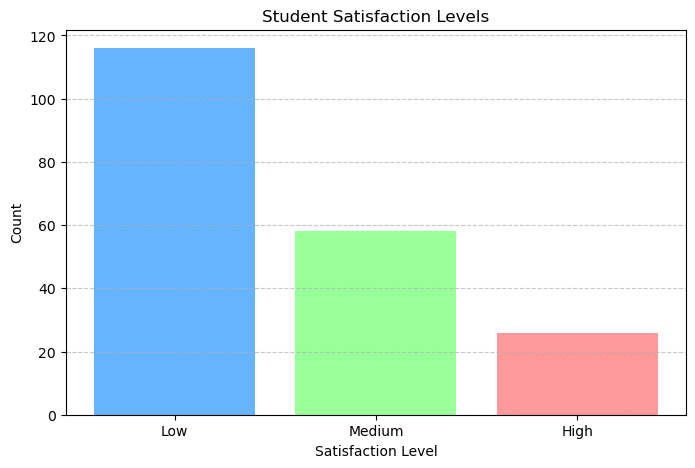


🔍 Chi-Square Test between Family_Income_Level and Satisfaction

Contingency Table:
Satisfaction         High  Low  Medium
Family_Income_Level                   
High                    8   19      20
Low                     6   44      18
Medium                 12   53      20

Chi-Square Statistic: 8.891
P-value: 0.0639
Degrees of Freedom: 4
❌ Fail to reject H0: No significant association found.

✅ Expanded Sales Dataset Created!
   Month  Advertising_Spend  Product_Price  Competition_Price  Monthly_Sales
0      1               1387             98                 95          -37.7
1      2               2422             90                 95          107.7
2      3               1141             95                 95          -37.4
3      4               2874             95                 95          113.1
4      5               1445             92                105           19.7

📈 Running Multiple Regression on Sales Data
                            OLS Regression Results       

In [42]:
# ==============================================
# Student Project: Expanded Dataset for Analysis
# ==============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency

# -------------------------------
# 1️⃣ CREATE EXPANDED STUDENT DATASET
# -------------------------------

np.random.seed(42)  # for reproducibility

# Generate 200 students (a bit more realistic size)
n_students = 200

student_df = pd.DataFrame({
    "StudentID": np.arange(1001, 1001 + n_students),
    "Attendance": np.random.randint(50, 100, n_students),
    "Weekly_Study_Hours": np.random.randint(3, 25, n_students),
    "Family_Income_Level": np.random.choice(["Low", "Medium", "High"], size=n_students, p=[0.35, 0.4, 0.25]),
})

# Now let's create Final_Grade influenced by study hours, attendance, and income
# A simple formula + random noise
student_df["Final_Grade"] = (
    0.4 * student_df["Attendance"]
    + 2.5 * student_df["Weekly_Study_Hours"]
    + student_df["Family_Income_Level"].map({"Low": -5, "Medium": 0, "High": 5})
    + np.random.normal(0, 5, n_students)
).round(1)

# Assign satisfaction based on performance (loosely correlated)
def assign_satisfaction(row):
    if row["Final_Grade"] >= 85:
        return np.random.choice(["High", "Medium"], p=[0.8, 0.2])
    elif row["Final_Grade"] >= 70:
        return np.random.choice(["Medium", "Low"], p=[0.7, 0.3])
    else:
        return np.random.choice(["Low", "Medium"], p=[0.8, 0.2])

student_df["Satisfaction"] = student_df.apply(assign_satisfaction, axis=1)

print("\n✅ Expanded Student Dataset Created!")
print(student_df.head())

# -------------------------------
# 2️⃣ FREQUENCY DISTRIBUTION (Satisfaction)
# -------------------------------
freq_table = student_df["Satisfaction"].value_counts().reset_index()
freq_table.columns = ["Satisfaction_Level", "Frequency"]
freq_table["Percentage"] = (freq_table["Frequency"] / len(student_df) * 100).round(1)

print("\n--- Frequency Distribution of Satisfaction ---")
print(freq_table)

plt.figure(figsize=(8, 5))
plt.bar(freq_table["Satisfaction_Level"], freq_table["Frequency"], color=["#66b3ff", "#99ff99", "#ff9999"])
plt.title("Student Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# -------------------------------
# 3️⃣ CHI-SQUARE TEST (Income vs Satisfaction)
# -------------------------------
print("\n🔍 Chi-Square Test between Family_Income_Level and Satisfaction")

contingency = pd.crosstab(student_df["Family_Income_Level"], student_df["Satisfaction"])
print("\nContingency Table:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Statistic: {chi2:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("✅ Reject H0: Significant association found!")
else:
    print("❌ Fail to reject H0: No significant association found.")

# -------------------------------
# 4️⃣ SALES DATASET FOR REGRESSION
# -------------------------------
# Expanding to 24 months so regression gives clearer p-values
months = np.arange(1, 25)

sales_df = pd.DataFrame({
    "Month": months,
    "Advertising_Spend": np.random.randint(800, 3000, len(months)),
    "Product_Price": np.random.choice([90, 92, 95, 98, 100], len(months)),
    "Competition_Price": np.random.choice([95, 97, 100, 102, 105, 108], len(months)),
})

# Monthly sales influenced by ad spend, product & competition price + random noise
sales_df["Monthly_Sales"] = (
    0.08 * sales_df["Advertising_Spend"]
    - 3.5 * sales_df["Product_Price"]
    + 2.0 * sales_df["Competition_Price"]
    + np.random.normal(0, 20, len(months))
).round(1)

print("\n✅ Expanded Sales Dataset Created!")
print(sales_df.head())

# -------------------------------
# 5️⃣ MULTIPLE REGRESSION MODEL
# -------------------------------
print("\n📈 Running Multiple Regression on Sales Data")

X = sales_df[["Advertising_Spend", "Product_Price", "Competition_Price"]].copy()
X["Advertising_Spend_k"] = X["Advertising_Spend"] / 1000  # scale down for readability
X = X[["Advertising_Spend_k", "Product_Price", "Competition_Price"]]
y = sales_df["Monthly_Sales"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

# -------------------------------
# 6️⃣ INTERPRETATION & NOTES
# -------------------------------
print("\n📘 Model Summary:")
print(f"R-squared: {model.rsquared:.3f}")
print(f"P-values:\n{model.pvalues.round(4)}")

print("\n💡 Interpretation:")
if (model.pvalues < 0.05).any():
    print("Some predictors are statistically significant (p < 0.05).")
else:
    print("No statistically significant predictors at 5% level.")

# Quick look at satisfaction trends
avg_grade_by_satisfaction = student_df.groupby("Satisfaction")["Final_Grade"].mean().round(2)
print("\nAverage Grade by Satisfaction Level:")
print(avg_grade_by_satisfaction)
